In [193]:
import os
import glob
import fnmatch
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
import seaborn as sns
import IPython.display as ipd
import random

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv1D, Conv2D, SeparableConv1D, MaxPooling1D, MaxPooling2D
from tensorflow.keras.layers import Input, add, Flatten, Dense, BatchNormalization, Dropout, LSTM, GRU, SimpleRNN, LSTM
from tensorflow.keras.layers import GlobalMaxPooling1D, GlobalMaxPooling2D, Activation, LeakyReLU, ReLU, Dropout

from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import cohen_kappa_score,roc_auc_score,confusion_matrix,classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras import layers
from keras_efficient_kan import KANLinear
from sklearn.metrics import confusion_matrix, roc_curve, auc

tf.config.list_physical_devices('GPU')
import sys
sys.executable

'c:\\Users\\MONSTER\\Desktop\\LungSoundAnlysis\\LungSoundAnlysis\\venv\\Scripts\\python.exe'

In [194]:
df = pd.read_csv("hasta_etiketler.csv", sep=";")
df["Teshis"] = df["Teshis"].replace({
    "COPD4": "COPD",
    "COPD3": "COPD",
    "COPD2": "COPD",
    "COPD1": "COPD",
    "COPD0": "COPD",
})
label_dict = dict(zip(df["ID"], df["Teshis"]))
label_dict["H001"] = "Healthy" 
label_dict

{'H001': 'Healthy',
 'H002': 'COPD',
 'H003': 'COPD',
 'H004': 'COPD',
 'H005': 'COPD',
 'H006': 'COPD',
 'H007': 'COPD',
 'H008': 'COPD',
 'H009': 'COPD',
 'H010': 'COPD',
 'H011': 'COPD',
 'H012': 'COPD',
 'H013': 'COPD',
 'H014': 'COPD',
 'H015': 'COPD',
 'H016': 'COPD',
 'H017': 'COPD',
 'H018': 'COPD',
 'H019': 'Asthma',
 'H020': 'Asthma',
 'H021': 'COPD',
 'H022': 'COPD',
 'H023': 'COPD',
 'H024': 'COPD',
 'H025': 'COPD',
 'H026': 'COPD',
 'H027': 'Asthma',
 'H028': 'COPD',
 'H029': 'COPD',
 'H030': 'COPD',
 'H031': 'COPD',
 'H032': 'COPD',
 'H033': 'COPD',
 'H034': 'COPD',
 'H035': 'COPD',
 'H036': 'COPD',
 'H037': 'COPD',
 'H038': 'COPD',
 'H039': 'COPD',
 'H040': 'COPD',
 'H041': 'COPD',
 'H042': 'COPD',
 'H043': 'COPD',
 'H044': 'COPD',
 'H045': 'COPD',
 'H046': 'Asthma',
 'H047': 'Asthma',
 'H048': 'Healthy',
 'H049': 'Healthy',
 'H050': 'COPD',
 'H051': 'Asthma',
 'H052': 'Healthy',
 'H053': 'Healthy',
 'H054': 'Healthy',
 'H055': 'Healthy',
 'H056': 'Healthy',
 'H057': 'He

In [195]:
asthma_data = "./Datasets/Asthma"
copd_data = "./Datasets/COPD4"
healthy_data = "./Datasets/Healthy"

print("Asthma files:", len(os.listdir(asthma_data)))
print("COPD files:", len(os.listdir(copd_data)))
print("Healthy files:", len(os.listdir(healthy_data)))

Asthma files: 96
COPD files: 112
Healthy files: 112


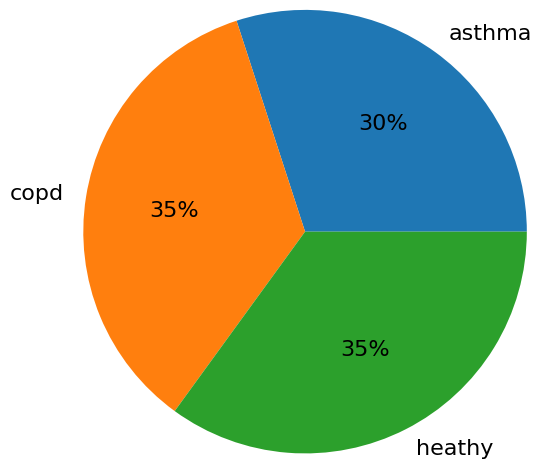

In [196]:
x = np.array([len(os.listdir(asthma_data)),
              len(os.listdir(copd_data)),
              len(os.listdir(healthy_data))])
labels = ['asthma', 'copd', 'heathy']
plt.pie(x, labels = labels, autopct = '%.0f%%', radius= 1.5, textprops={'fontsize': 16})
plt.show()

In [197]:
def random_sound (audio_class):
    random_sound = np.random.randint(0,len(os.listdir(audio_class))) 
    sound = os.listdir(audio_class)[random_sound]
    sound = audio_class+"/"+sound
    sound,sample_rate = librosa.load(sound)
    return ipd.Audio(sound,rate=sample_rate),sound

def show_audio_waveform(audio_sample):
    plt.figure(figsize=(20,5))
    librosa.display.waveshow(audio_sample, sr = 22050)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

def show_audio_spectrum(audio_sample):
    sample_rate = 22050
    fft_normal = np.fft.fft(audio_sample)
    magnitude_normal = np.abs(fft_normal)
    freq_normal = np.linspace(0,sample_rate, len(magnitude_normal)) 
    half_freq = freq_normal[:int(len(freq_normal)/2)]
    half_magnitude = magnitude_normal[:int(len(freq_normal)/2)]

    plt.figure(figsize=(12,8))
    plt.plot(half_freq,half_magnitude)
    plt.title("Spectrum")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()

def show_spectrogram (audio_sample):
    hop_length = 512
    n_fft = 2048
    sample_rate = 22050

    hop_length_duration = float(hop_length)/sample_rate
    n_fft_duration = float(n_fft)/sample_rate

    print("STFT hop length duration is: {}s".format(hop_length_duration))
    print("STFT window duration is: {}s".format(n_fft_duration))

    stft_normal = librosa.stft(audio_sample, n_fft=n_fft, hop_length=hop_length)

    spectrogram = np.abs(stft_normal)
    log_spectrogram = librosa.amplitude_to_db(spectrogram)

    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    #plt.set_cmap("YlOrBr")
    plt.title("Spectrogram")

def show_mfcc_features(audio_sample):
    hop_length = 512
    n_fft = 2048
    sample_rate = 22050
    
    MFCCs = librosa.feature.mfcc(y=audio_sample, sr=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mfcc=52)

    # display MFCCs
    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCCs, x_axis='time', sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("MFCC coefficients")
    plt.colorbar()
    plt.title("MFCCs")
    plt.show()

In [198]:
asthma_audio, asthma_sample  = random_sound(asthma_data)
asthma_audio

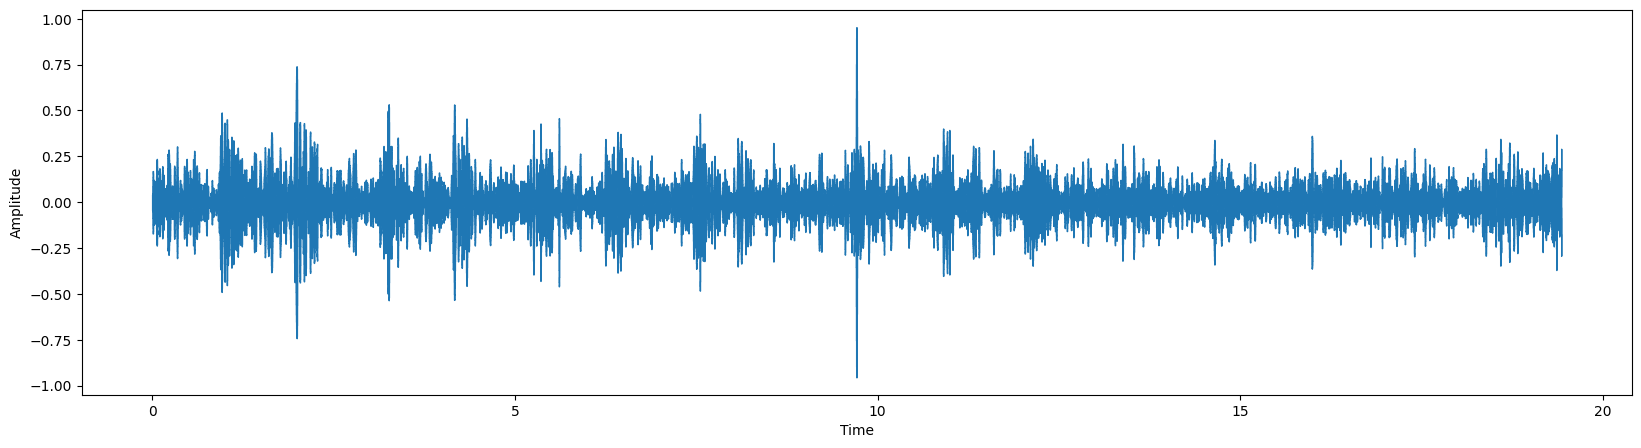

In [199]:
show_audio_waveform(asthma_sample)

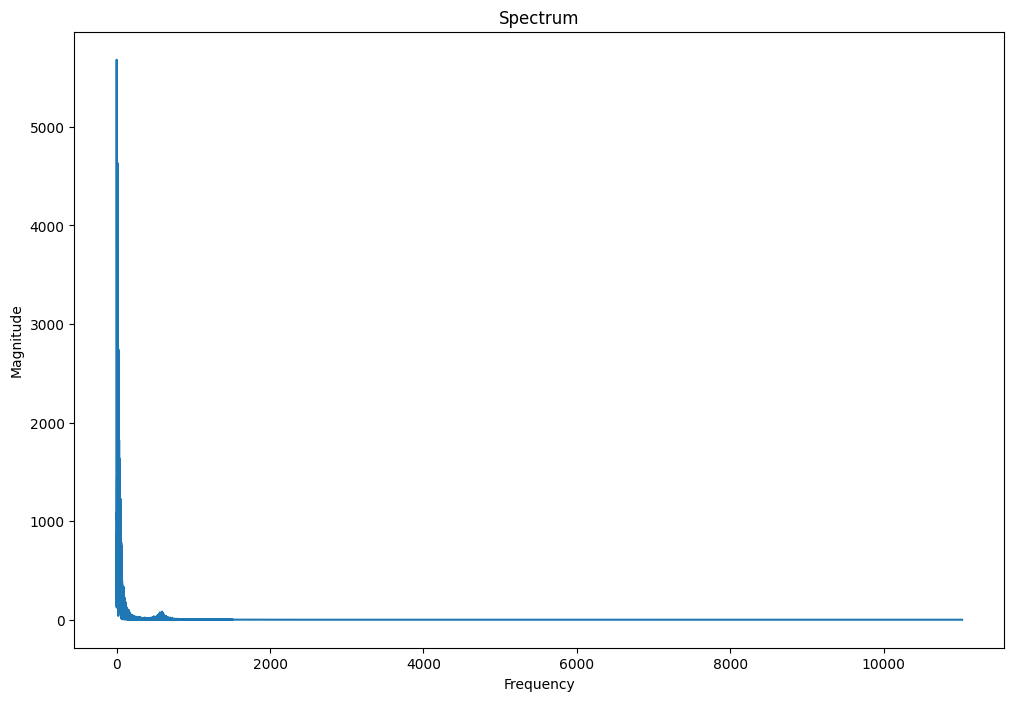

In [200]:
show_audio_spectrum(asthma_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


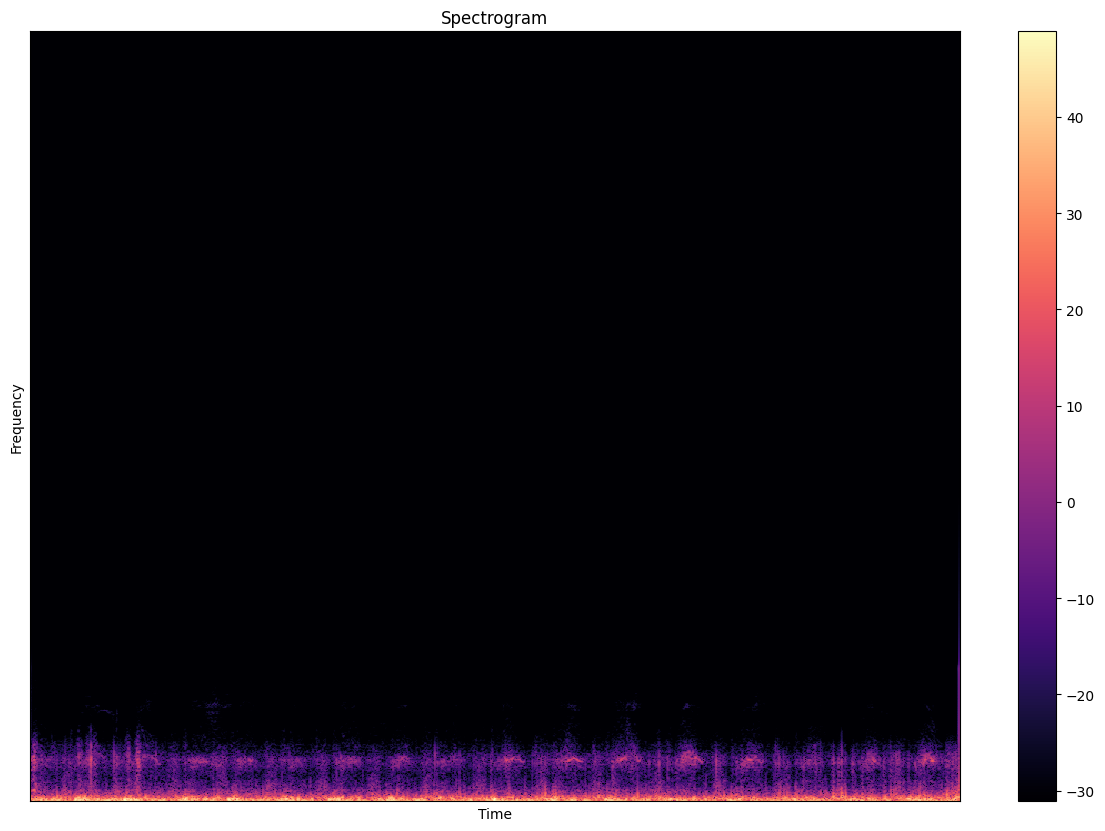

In [201]:
show_spectrogram(asthma_sample)

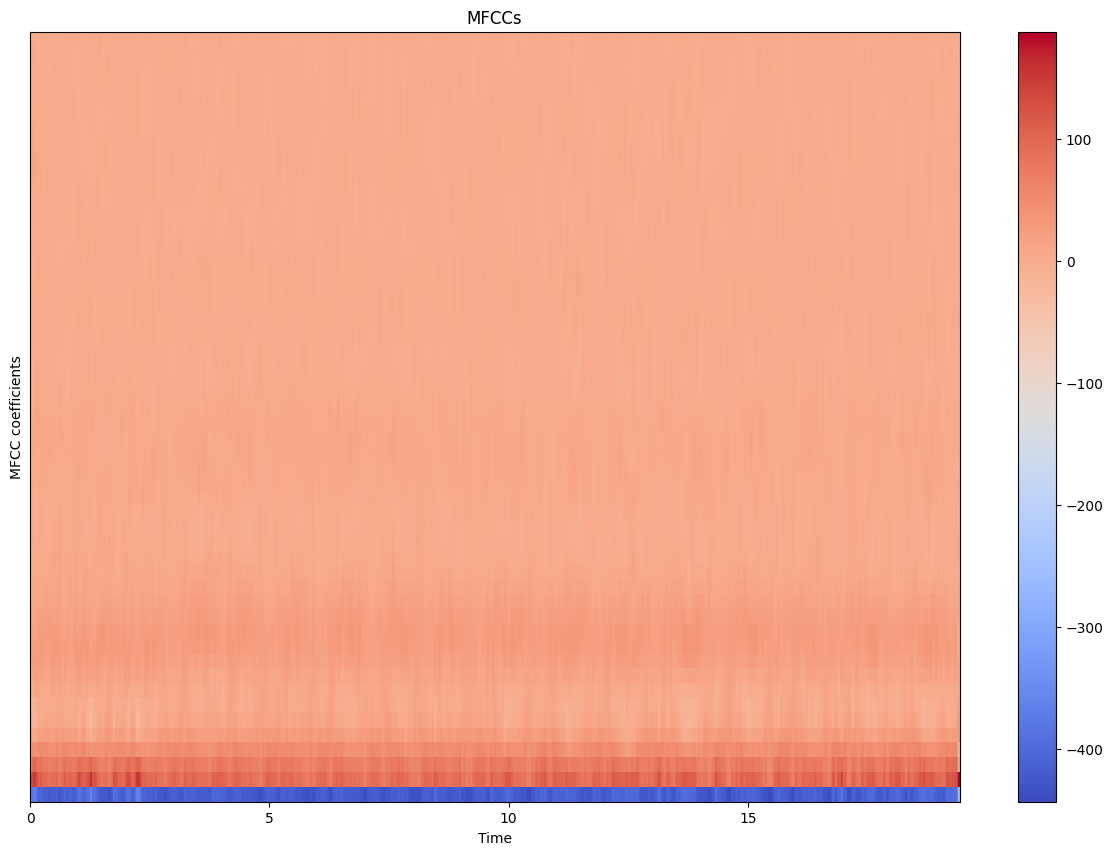

In [202]:
show_mfcc_features(asthma_sample)

In [203]:
def augment_noise(audio, sr=None):
    noise = np.random.randn(len(audio))
    return audio + 0.005 * noise

def augment_pitch(audio, sr):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=random.uniform(-2, 2))

def augment_speed(audio, sr):
    speed = random.uniform(0.9, 1.1)
    return librosa.effects.time_stretch(audio, rate=speed)

def apply_augmentations(audio, sr=22050):
    funcs = [
        lambda y: augment_noise(y),
        lambda y: augment_pitch(y, sr),
        lambda y: augment_speed(y, sr)
    ]
    func = random.choice(funcs)
    return func(audio)


In [204]:
def extract_mfcc(audio, sr=22050):
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=100, n_fft=2048, hop_length=512
    )
    return mfcc.T

In [205]:
class_folders = {
    "Asthma": asthma_data,
    "COPD": copd_data,
    "Healthy": healthy_data
}

X_features = []
y_labels = []

for label, folder in class_folders.items():
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        audio, sr = librosa.load(path, sr=22050)

        # Orijinal
        X_features.append(extract_mfcc(audio))
        y_labels.append(label)

        # Augmented
        audio_aug = apply_augmentations(audio)
        X_features.append(extract_mfcc(audio_aug))
        y_labels.append(label)


In [206]:
X_padded = pad_sequences(
    X_features,
    padding="post",
    dtype="float32"
)

X = np.array(X_padded)
y = np.array(y_labels)


In [207]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)


In [208]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)


In [209]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


In [210]:
def build_mlp(input_dim, num_classes=3, lr=1e-4):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [211]:
def build_svm(input_dim, num_classes=3, C=10, kernel='rbf'):
    model = SVC(
        C=C,
        kernel=kernel,
        gamma='scale',
        probability=True
    )
    return model


In [212]:
def build_knn(input_dim, num_classes=3, k=5):
    model = KNeighborsClassifier(n_neighbors=k)
    return model

In [213]:
def build_cnn(input_shape, num_classes=3):
    model = Sequential([
        Conv1D(64, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [214]:
def build_kan_model(input_dim, num_classes):
    model = Sequential([
        layers.Input(shape=(input_dim,)),

        KANLinear(units=64),
        BatchNormalization(),
        layers.Dropout(0.3),

        KANLinear(units=128),
        BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [215]:
seq_input = (X_train.shape[1], X_train.shape[2])  # (time, 52)
flat_input = X_train_flat.shape[1]
num_classes = y_train.shape[1]


c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: MLP
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


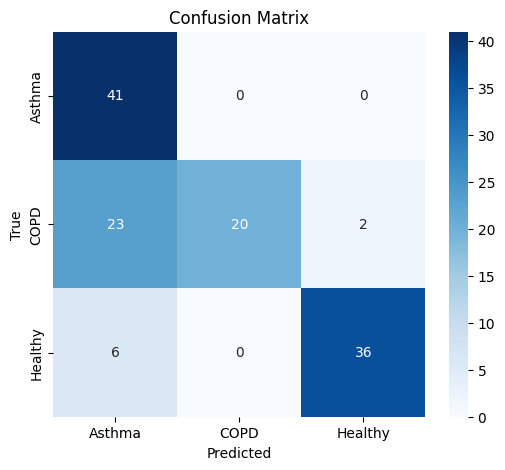

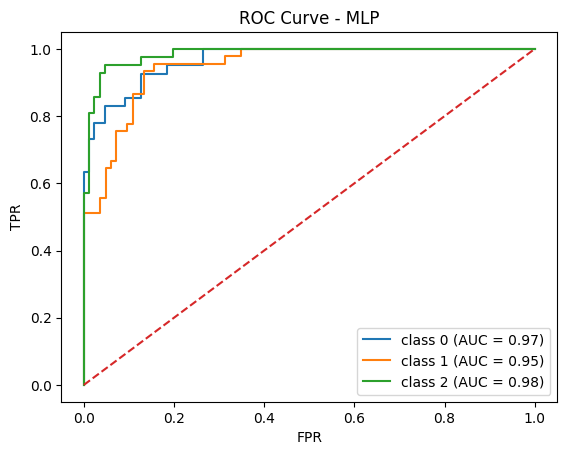

F1 Score: 0.7482859060984062
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        41
           1       1.00      0.44      0.62        45
           2       0.95      0.86      0.90        42

    accuracy                           0.76       128
   macro avg       0.84      0.77      0.75       128
weighted avg       0.85      0.76      0.75       128


Training: SVM


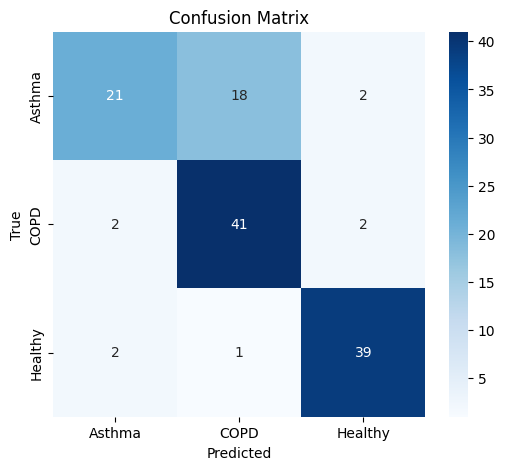

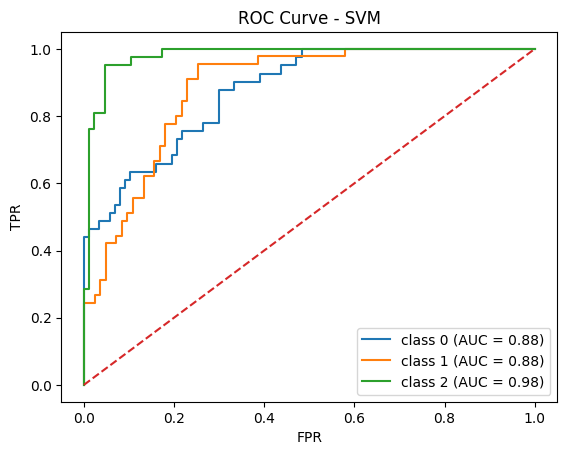

F1 Score: 0.7794917398777692
              precision    recall  f1-score   support

           0       0.84      0.51      0.64        41
           1       0.68      0.91      0.78        45
           2       0.91      0.93      0.92        42

    accuracy                           0.79       128
   macro avg       0.81      0.78      0.78       128
weighted avg       0.81      0.79      0.78       128


Training: CNN
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


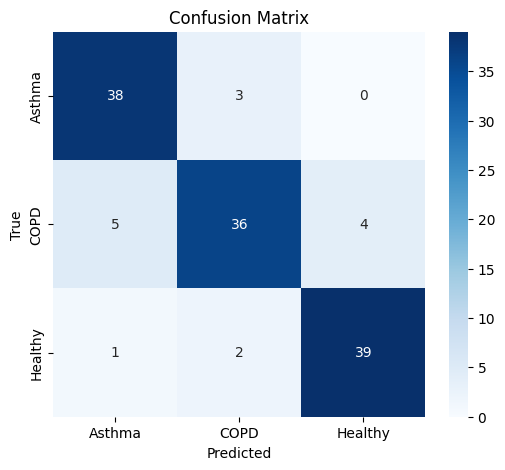

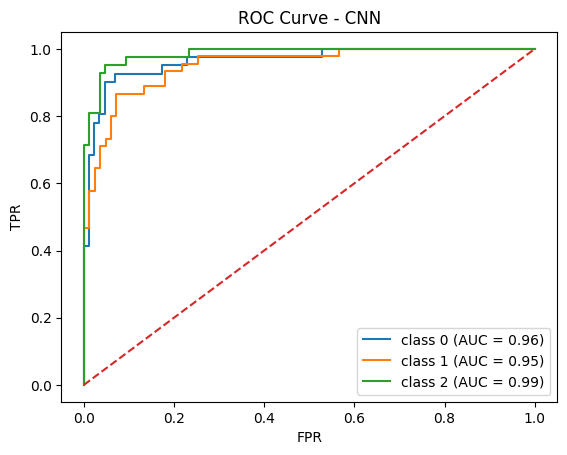

F1 Score: 0.8818313953488373
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        41
           1       0.88      0.80      0.84        45
           2       0.91      0.93      0.92        42

    accuracy                           0.88       128
   macro avg       0.88      0.89      0.88       128
weighted avg       0.88      0.88      0.88       128


Training: KNN


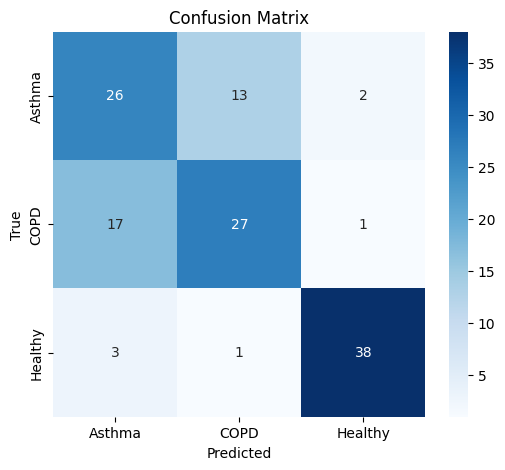

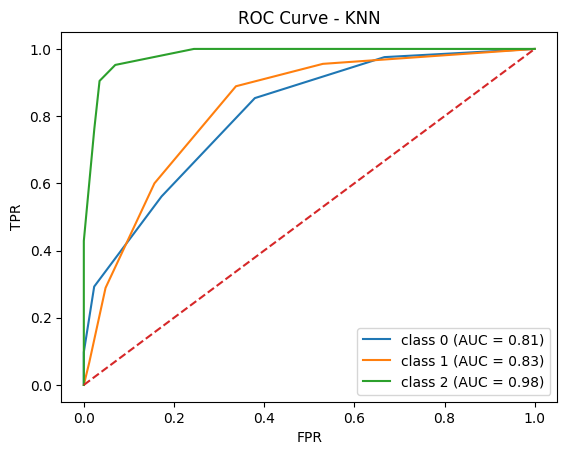

F1 Score: 0.7126515031658309
              precision    recall  f1-score   support

           0       0.57      0.63      0.60        41
           1       0.66      0.60      0.63        45
           2       0.93      0.90      0.92        42

    accuracy                           0.71       128
   macro avg       0.72      0.71      0.71       128
weighted avg       0.72      0.71      0.71       128


Training: KAN
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 677ms/step


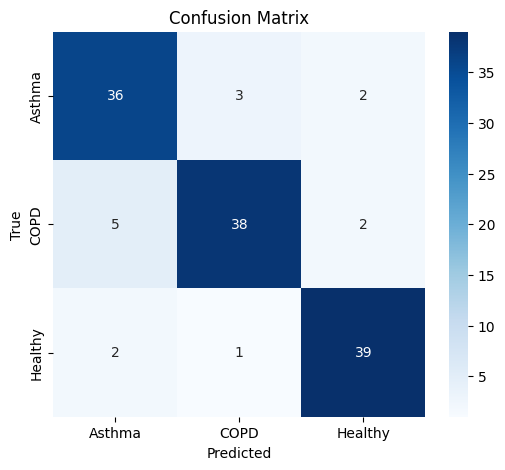

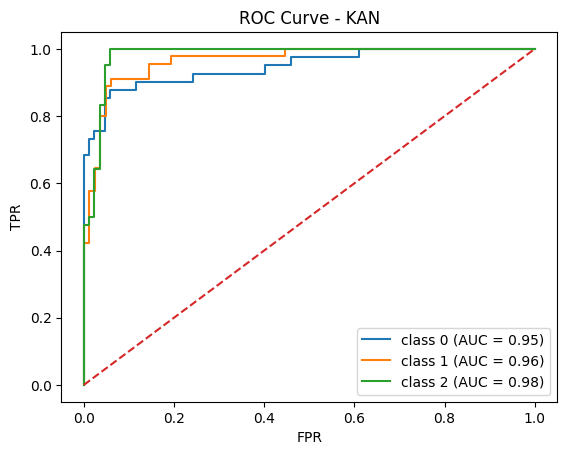

F1 Score: 0.8827685815705593
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        41
           1       0.90      0.84      0.87        45
           2       0.91      0.93      0.92        42

    accuracy                           0.88       128
   macro avg       0.88      0.88      0.88       128
weighted avg       0.88      0.88      0.88       128



In [216]:
models = {
    "MLP": build_mlp(flat_input, num_classes),
    "SVM": build_svm(flat_input, num_classes),
    "CNN": build_cnn(seq_input, num_classes),
    "KNN": build_knn(flat_input, num_classes),
    "KAN": build_kan_model(flat_input,num_classes)
}

results = {}

for name, model in models.items():
    print("\nTraining:", name)

    # DL modeller
    if name in ["MLP", "CNN","KAN"]:
        model.fit(
            X_train_flat if (name=="MLP" or name=="KAN") else X_train,
            y_train,
            validation_data=(
                X_test_flat if (name=="MLP" or name=="KAN") else X_test,
                y_test),
            epochs=100, 
            batch_size=32,
            verbose=0
        )

        y_proba = model.predict(
            X_test_flat if (name=="MLP" or name=="KAN") else X_test
        )
        preds = np.argmax(y_proba, axis=1)

    # klasik modeller
    else:
        model.fit(X_train_flat, y_train.argmax(axis=1))
        preds = model.predict(X_test_flat)
        # proba destekleyenlerde ROC
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_flat)
        else:
            # ROC yoksa dummy
            y_proba = np.zeros((len(preds), num_classes))


    # Confusion Matrix
    y_true = y_test.argmax(axis=1)
    
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # ROC
    try:
        # one hot target gerekli
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

            plt.plot(fpr[i], tpr[i], label=f'class {i} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.show()

    except:
        print(f"ROC not available for {name}")


    # F1 score
    f1 = f1_score(y_true, preds, average="weighted")
    results[name] = f1
    print("F1 Score:", f1)
    print(classification_report(y_true, preds))